In [38]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import os
from sklearn.cross_decomposition import PLSRegression
from rdkit import Chem
# from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors
import rdkit
rdkit.__version__

'2022.09.5'

In [39]:
data = pd.read_csv('data.csv')
print(data.head())

  id  yield  singleddg   totalddg   spin
0  a     87   -23.4551 -83.127438  0.763
1  b     27   -24.8055 -84.489762  0.760
2  c     57   -23.9665 -83.146264  0.773
3  d     41   -23.8711 -83.235370  0.762
4  e     46   -23.5592 -83.200857  0.758


In [40]:
y = data["yield"].values.tolist()
# log transform the data
y = np.log(y)
y = y.reshape(-1, 1)


In [41]:

def getMolDescriptors(mol, missingVal=None):
    ''' calculate the full list of descriptors for a molecule
    
        missingVal is used if the descriptor cannot be calculated
    '''
    res = {}
    for nm,fn in Descriptors._descList:
        # some of the descriptor fucntions can throw errors if they fail, catch those here:
        try:
            val = fn(mol)
        except:
            # print the error message:
            import traceback
            traceback.print_exc()
            # and set the descriptor value to whatever missingVal is
            val = missingVal
        res[nm] = val
    return res
        



In [42]:
sdf_test ="/mnt/g/zqy/mols/3f_RC.sdf"
# sdf_test ="./mols/5zcu_ligand.sdf"
# get_MolMR_from_sdf(sdf_test)
mol = Chem.MolFromMolFile(sdf_test)
mol = mol
Des = getMolDescriptors(mol)
# print(type(Des))
print(Des)
print(Des['MolMR'])


{'MaxEStateIndex': 5.747808641975308, 'MinEStateIndex': 0.7643518518518522, 'MaxAbsEStateIndex': 5.747808641975308, 'MinAbsEStateIndex': 0.7643518518518522, 'qed': 0.578998062285493, 'MolWt': 152.624, 'HeavyAtomMolWt': 143.55199999999996, 'ExactMolWt': 152.039277968, 'NumValenceElectrons': 52, 'NumRadicalElectrons': 0, 'MaxPartialCharge': 0.04115430407893817, 'MinPartialCharge': -0.09551530133445335, 'MaxAbsPartialCharge': 0.09551530133445335, 'MinAbsPartialCharge': 0.04115430407893817, 'FpDensityMorgan1': 1.5, 'FpDensityMorgan2': 2.2, 'FpDensityMorgan3': 2.6, 'BCUT2D_MWHI': 35.49569081303627, 'BCUT2D_MWLOW': 10.112233572014143, 'BCUT2D_CHGHI': 1.9128040988485329, 'BCUT2D_CHGLO': -1.9715162310419, 'BCUT2D_LOGPHI': 2.15523022504191, 'BCUT2D_LOGPLOW': -1.7457658037533124, 'BCUT2D_MRHI': 6.302639571601947, 'BCUT2D_MRLOW': 1.581652950115334, 'BalabanJ': 3.0698992657592745, 'BertzCT': 250.66010836790298, 'Chi0': 7.560477932315067, 'Chi0n': 5.894472330954278, 'Chi0v': 6.650401276972732, 'Chi

# calculate des

In [43]:
molecules_name = os.listdir('mols')
molecules_path = ['mols/' + i for i in molecules_name]
des_dicts = []
for i in molecules_path:
    mol = Chem.MolFromMolFile(i)
    mol = mol
    Des = getMolDescriptors(mol)
    des_dicts.append(Des)



In [44]:
x1 = data["singleddg"].values.tolist()
x2 = data["totalddg"].values.tolist()
x3 = data["spin"].values.tolist()
x4 = [i['TPSA'] for i in des_dicts]
x5 = [i['MolMR'] for i in des_dicts]
print(len(x4))
print(len(x3))
x = np.column_stack((x1, x2, x3,x4, x5)) #
print(x)
# standardize the data
x = (x - x.mean(axis=0)) / x.std(axis=0)
print(x)

12
12
[[-23.4551     -83.12743848   0.763        0.          41.15      ]
 [-24.8055     -84.48976161   0.76         0.          41.108     ]
 [-23.9665     -83.14626377   0.773        9.23        47.702     ]
 [-23.8711     -83.23537012   0.762        0.          45.887     ]
 [-23.5592     -83.2008571    0.758        0.          41.108     ]
 [-23.494      -83.1745017    0.758        0.          46.16      ]
 [-23.6395     -82.63672606   0.757        9.23        47.702     ]
 [-22.3186     -82.104598     0.76         0.          45.887     ]
 [-24.2357     -83.392875     0.764        0.          41.108     ]
 [-23.5624     -83.19646453   0.751        0.          46.16      ]
 [-22.9486     -83.40856274   0.72        28.37        52.4895    ]
 [-23.4871     -82.26524043   0.755       18.46        54.254     ]]
[[ 2.65764123e-01 -2.15809046e-02  5.11127400e-01 -6.08055961e-01
  -1.13031092e+00]
 [-2.02245354e+00 -2.36418905e+00  2.65786248e-01 -6.08055961e-01
  -1.14032009e+00]
 [-6.00

In [45]:
# # add the used descriptors to the data frame
# data['TPSA'] = x4
# data['MolMR'] = x5
# data.to_csv('data_with_descriptors.csv', index=False)

In [46]:
# fit the model using PLSR
print(x.shape)
print(y.shape)
train = 0.6
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=train,random_state=24)

pls2 = PLSRegression(n_components=2)
pls2.fit(x_train, y_train)
# get the training data
y_pred_train = pls2.predict(x_train)
y_pred = pls2.predict(x_test)
# print(y_pred)

#  pearson correlation
from scipy.stats import pearsonr
y_pred = y_pred.flatten()
y_test = y_test.flatten()
y_pred_train = y_pred_train.flatten()
y_train = y_train.flatten()
R_train = pearsonr(y_pred_train, y_train)
R_test = pearsonr(y_pred, y_test)

print("num_train:", len(y_train))
print("num_test:", len(y_test))

print("pearsonr test: ", R_test[0])
print("pearsonr train: ", R_train[0])


print(pls2.coef_)
print("y = ", pls2.coef_[0][0], "x1 + ", pls2.coef_[1][0], "x2 + ", pls2.coef_[2][0], "x3 + ", pls2.coef_[3][0], "x4 + ", pls2.coef_[4][0], "x5")



(12, 5)
(12, 1)
num_train: 7
num_test: 5
pearsonr test:  0.7217569745254191
pearsonr train:  0.8466779886124582
[[ 0.02526445]
 [ 0.36886769]
 [ 0.11436328]
 [ 0.3689784 ]
 [-0.46363509]]
y =  0.025264446716583656 x1 +  0.3688676882447854 x2 +  0.11436328112060258 x3 +  0.36897839902821855 x4 +  -0.46363508942689674 x5


/home/luod/miniconda3/envs/tankbind/lib/python3.8/site-packages/sklearn/cross_decomposition/_pls.py:507: FutureWarning: The attribute `coef_` will be transposed in version 1.3 to be consistent with other linear models in scikit-learn. Currently, `coef_` has a shape of (n_features, n_targets) and in the future it will have a shape of (n_targets, n_features).
  warnings.warn(


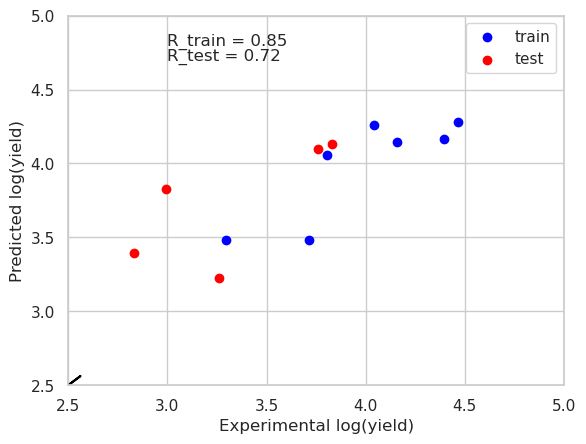

In [47]:
# plot the training and test data
import matplotlib.pyplot as plt
plt.scatter(y_train, y_pred_train, color='blue', label='train')
plt.scatter(y_test, y_pred, color='red', label='test')
# set the same scale
plt.xlim(2.5, 5)
plt.ylim(2.5, 5)
plt.legend()
plt.xlabel('Experimental log(yield)')
plt.ylabel('Predicted log(yield)')

# show the fit line and the coefficient
y_x = np.linspace(2.5, 5, 100)
y_x = x
plt.plot(y_x, y_x, color='black')
# showing the fited  R_train and R_test in the plot
plt.text(3, 4.8, 'R_train = %.2f' % R_train[0])
plt.text(3, 4.7, 'R_test = %.2f' % R_test[0])


plt.show()


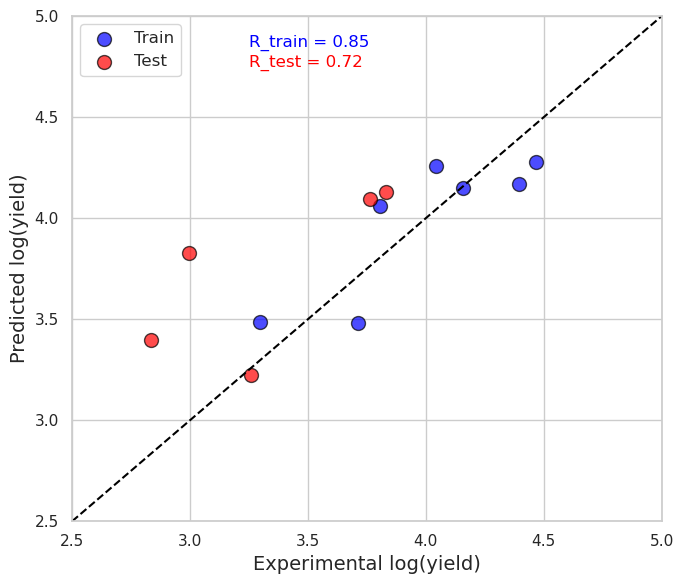

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set the advanced Seaborn style
# sns.set_theme(style="ticks") # darkgrid, whitegrid, dark, white, ticks
sns.set_theme(style="whitegrid")

# Create a scatter plot with train and test data
plt.figure(figsize=(7, 6))
plt.scatter(y_train, y_pred_train, color='blue', label='Train', s=100, edgecolor='black', alpha=0.7)
plt.scatter(y_test, y_pred, color='red', label='Test', s=100, edgecolor='black', alpha=0.7)

# Set the same scale for x and y axes
plt.xlim(2.5, 5)
plt.ylim(2.5, 5)

# Plot the diagonal line (perfect prediction)
y_x = np.linspace(2.5, 5, 100)
plt.plot(y_x, y_x, color='black', linestyle='--')

# Adjust the positions of R_train and R_test
# Placing R_train in the upper-left corner and R_test in the upper-right corner
plt.text(3.25, 4.85, f'R_train = {R_train[0]:.2f}', fontsize=12, color='blue', ha='left')
plt.text(3.25, 4.75, f'R_test = {R_test[0]:.2f}', fontsize=12, color='red', ha='left')

# Labels and legend
plt.xlabel('Experimental log(yield)', fontsize=14)
plt.ylabel('Predicted log(yield)', fontsize=14)
plt.legend(fontsize=12)

# Show the plot
plt.tight_layout()
plt.savefig('pls.svg', format='svg')
plt.show()
